First 5 rows:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean

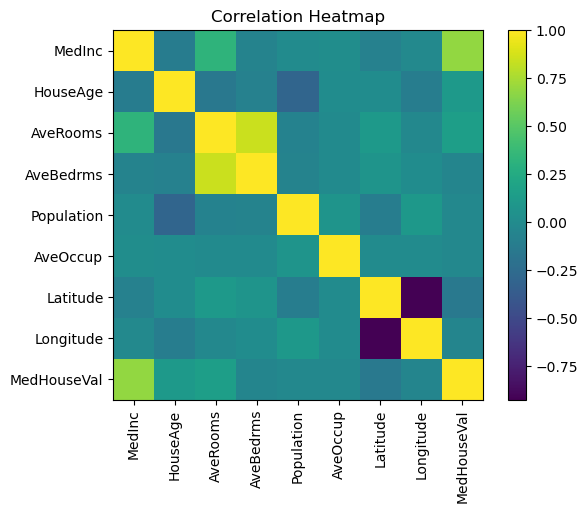


Mean Squared Error: 0.5558548589435972
R2 Score: 0.5758157428913682

Feature Importance:
       Feature  Coefficient
0      MedInc     0.854327
1    HouseAge     0.122624
2    AveRooms    -0.294210
3   AveBedrms     0.339008
4  Population    -0.002282
5    AveOccup    -0.040833
6    Latitude    -0.896168
7   Longitude    -0.869071


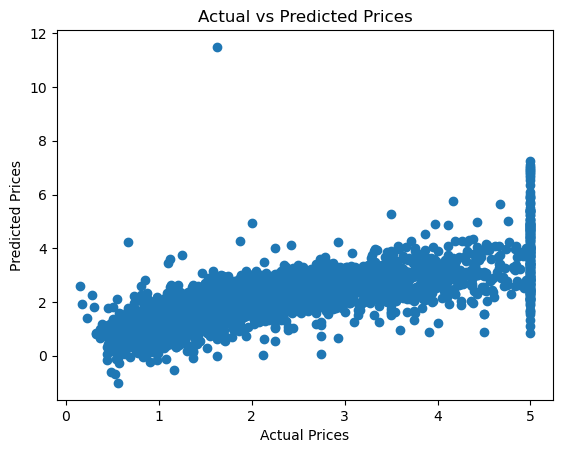

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# -------------------------------
# 2. Explore Data
# -------------------------------
print("First 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

# Correlation heatmap
plt.figure()
plt.imshow(df.corr(), interpolation='nearest')
plt.title("Correlation Heatmap")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.show()

# -------------------------------
# 3. Prepare Data
# -------------------------------
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# 4. Build Ridge Model
# -------------------------------
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# -------------------------------
# 5. Evaluate Model
# -------------------------------
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# -------------------------------
# 6. Interpret Coefficients
# -------------------------------
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:\n", coefficients)

# -------------------------------
# 7. Plot Predicted vs Actual
# -------------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()